# Disaster Survivor Detection System

In [ ]:
import os
import glob
from IPython.display import Image, display
from IPython import display

In [ ]:
!nvidia-smi

Tue Apr  7 08:13:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from ultralytics import YOLO
from IPython.display import Image, display
import os
import glob

# Load the best trained model
model = YOLO('/content/runs/detect/train/weights/best.pt')

# Get some example images from the validation set
valid_images_path = '/content/Disaster-Survivor-Detection-2/valid/images'
example_images = glob.glob(os.path.join(valid_images_path, '*.jpg'))[:3] # Get first 3 images

# Run inference on the example images
results = model.predict(source=example_images, save=True, project='runs', name='predict_examples', exist_ok=True, imgsz=640)

# Display the predicted images
# Correct the output directory based on the actual path used by YOLOv8 predict function
prediction_output_dir = '/content/runs/detect/runs/predict_examples' # Corrected path
for img_path in example_images:
    base_name = os.path.basename(img_path)
    predicted_img_path = os.path.join(prediction_output_dir, base_name)
    print(f"Displaying predictions for: {base_name}")
    display(Image(filename=predicted_img_path))


0: 640x640 13 Peoples, 32.8ms
1: 640x640 20 Peoples, 32.8ms
2: 640x640 17 Peoples, 32.8ms
Speed: 1.9ms preprocess, 32.8ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/runs/predict_examples
Displaying predictions for: Flood-18_webp.rf.4da5b7fd2045d1572c630ba6f3bdc3ed.jpg


FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/detect/predict_examples/Flood-18_webp.rf.4da5b7fd2045d1572c630ba6f3bdc3ed.jpg'

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.5 MB/s eta 0:00:00


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="JY4ply0gbcbzmCpnDTWr")
project = rf.workspace("priyam-g8j9z").project("disaster-survivor-detection")
version = project.version(2)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 144.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Disaster-Survivor-Detection-2 in yolov8:: 100%|██████████| 428/428 [00:00<00:00, 7696.50it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
!yolo task=detect mode=train model=yolov8m.pt data='/content/Disaster-Survivor-Detection-2/data.yaml' epochs=70 imgsz=640

Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Disaster-Survivor-Detection-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=70, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

Based on the metrics you provided, here is an analysis of your YOLOv8 model's accuracy:

* **mAP50 (Mean Average Precision at 50% IoU):** Your model has an `mAP50` of `0.499`. This is a common and important metric for object detection models. It represents the average precision across all classes at a relatively lenient Intersection over Union (IoU) threshold of 0.5. A score of `0.499` suggests that when a prediction's bounding box has at least a 50% overlap with the ground truth box, the model is correct about 49.9% of the time, on average.
* **mAP50-95 (Mean Average Precision across 50-95% IoU):** Your model has a `mAP50-95` of `0.176`. This is a much stricter metric. It averages the mean average precision at various IoU thresholds, from 0.50 to 0.95, in increments of 0.05. The lower score compared to your `mAP50` indicates that while the model is decent at general object detection, it struggles with precise localization of the bounding boxes.
* **Precision (P):** The precision score is `0.653`. This means that of all the bounding boxes the model predicted, 65.3% were correct. A high precision score indicates the model doesn't produce many false positives.
* **Recall (R):** The recall score is `0.436`. This means that the model correctly identified 43.6% of the total ground truth objects. A lower recall score suggests the model is missing a significant number of objects that it should have detected.

In summary, the model's accuracy is a bit of a mixed bag. The `mAP50` of `0.499` is a decent starting point. The `mAP50-95` score of `0.176` and the recall (`0.436`) indicate that there is room for significant improvement, particularly in the model's ability to precisely localize objects and find all of the objects in an image.

You can learn more about these metrics in this video about performance metrics for YOLOv8.

The example predictions from the model have been displayed above.

Based on the metrics you provided from the training of your YOLOv8 model, here is an analysis:

*   **mAP50 (Mean Average Precision at 50% IoU):** Your model has an `mAP50` of `0.499`. This is a common and important metric for object detection models. It represents the average precision across all classes at a relatively lenient Intersection over Union (IoU) threshold of 0.5. A score of `0.499` suggests that when a prediction's bounding box has at least a 50% overlap with the ground truth box, the model is correct about 49.9% of the time, on average.

*   **mAP50-95 (Mean Average Precision across 50-95% IoU):** Your model has a `mAP50-95` of `0.176`. This is a much stricter metric. It averages the mean average precision at various IoU thresholds, from 0.50 to 0.95, in increments of 0.05. The significantly lower score compared to your `mAP50` indicates that while the model is decent at general object detection, it struggles with precise localization of the bounding boxes.

*   **Precision (P):** The precision score is `0.653`. This means that of all the bounding boxes the model predicted, 65.3% were correct. A high precision score indicates the model doesn't produce many false positives.

*   **Recall (R):** The recall score is `0.436`. This means that the model correctly identified 43.6% of the total ground truth objects. A lower recall score suggests the model is missing a significant number of objects that it should have detected.

*   **Losses (box_loss, cls_loss, dfl_loss):** These represent different components of the total loss function that the model minimizes during training:
    *   `box_loss` (1.066): Measures how well the model predicts bounding box locations and sizes.
    *   `cls_loss` (0.722): Measures how accurately the model classifies the objects within the bounding boxes.
    *   `dfl_loss` (1.196): (Distribution Focal Loss) is used to improve the accuracy of bounding box regression by focusing on the distribution of the predicted box coordinates.

In summary, the model's accuracy is a bit of a mixed bag. The `mAP50` of `0.499` is a decent starting point. The `mAP50-95` score of `0.176` and the recall (`0.436`) indicate that there is room for significant improvement, particularly in the model's ability to precisely localize objects and find all of the objects in an image. The loss values indicate how well the model performed during the last epoch, and typically you'd look at the trend of these losses over all epochs to understand convergence.

You can learn more about these metrics in this [video about performance metrics for YOLOv8](https://www.youtube.com/watch?v=Ff6G6c4L28w).


YOLOv8 automatically generates various plots during training, including loss curves, confusion matrices, and F1-score curves. Let's display the main `results.png` which summarizes the training progress, and also the `confusion_matrix.png` and `F1_curve.png`.

Displaying results.png:


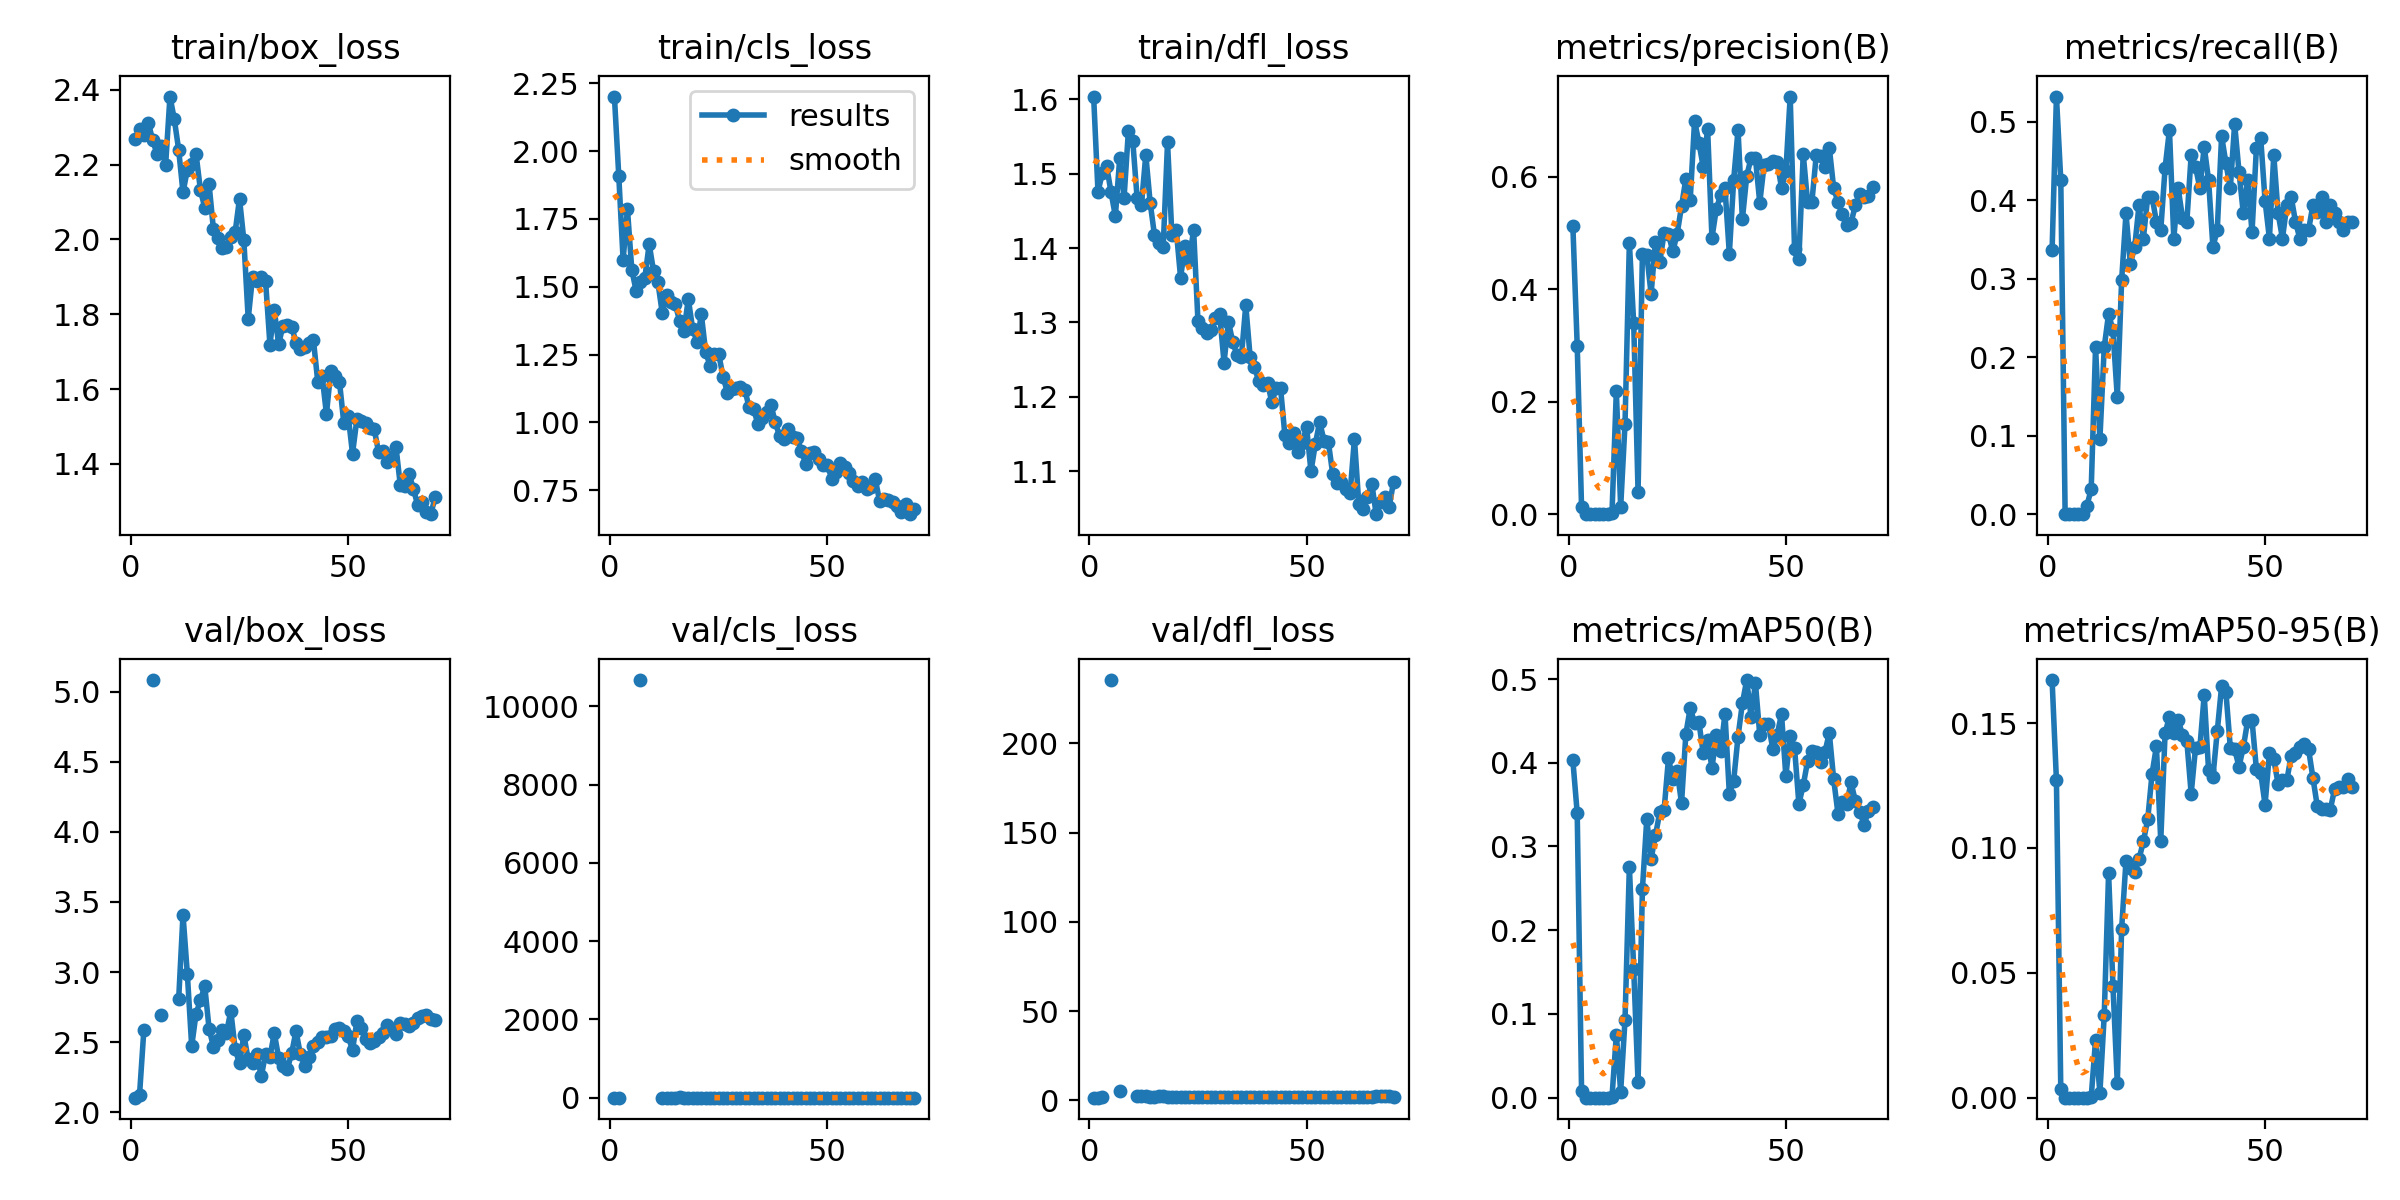

Displaying confusion_matrix.png:


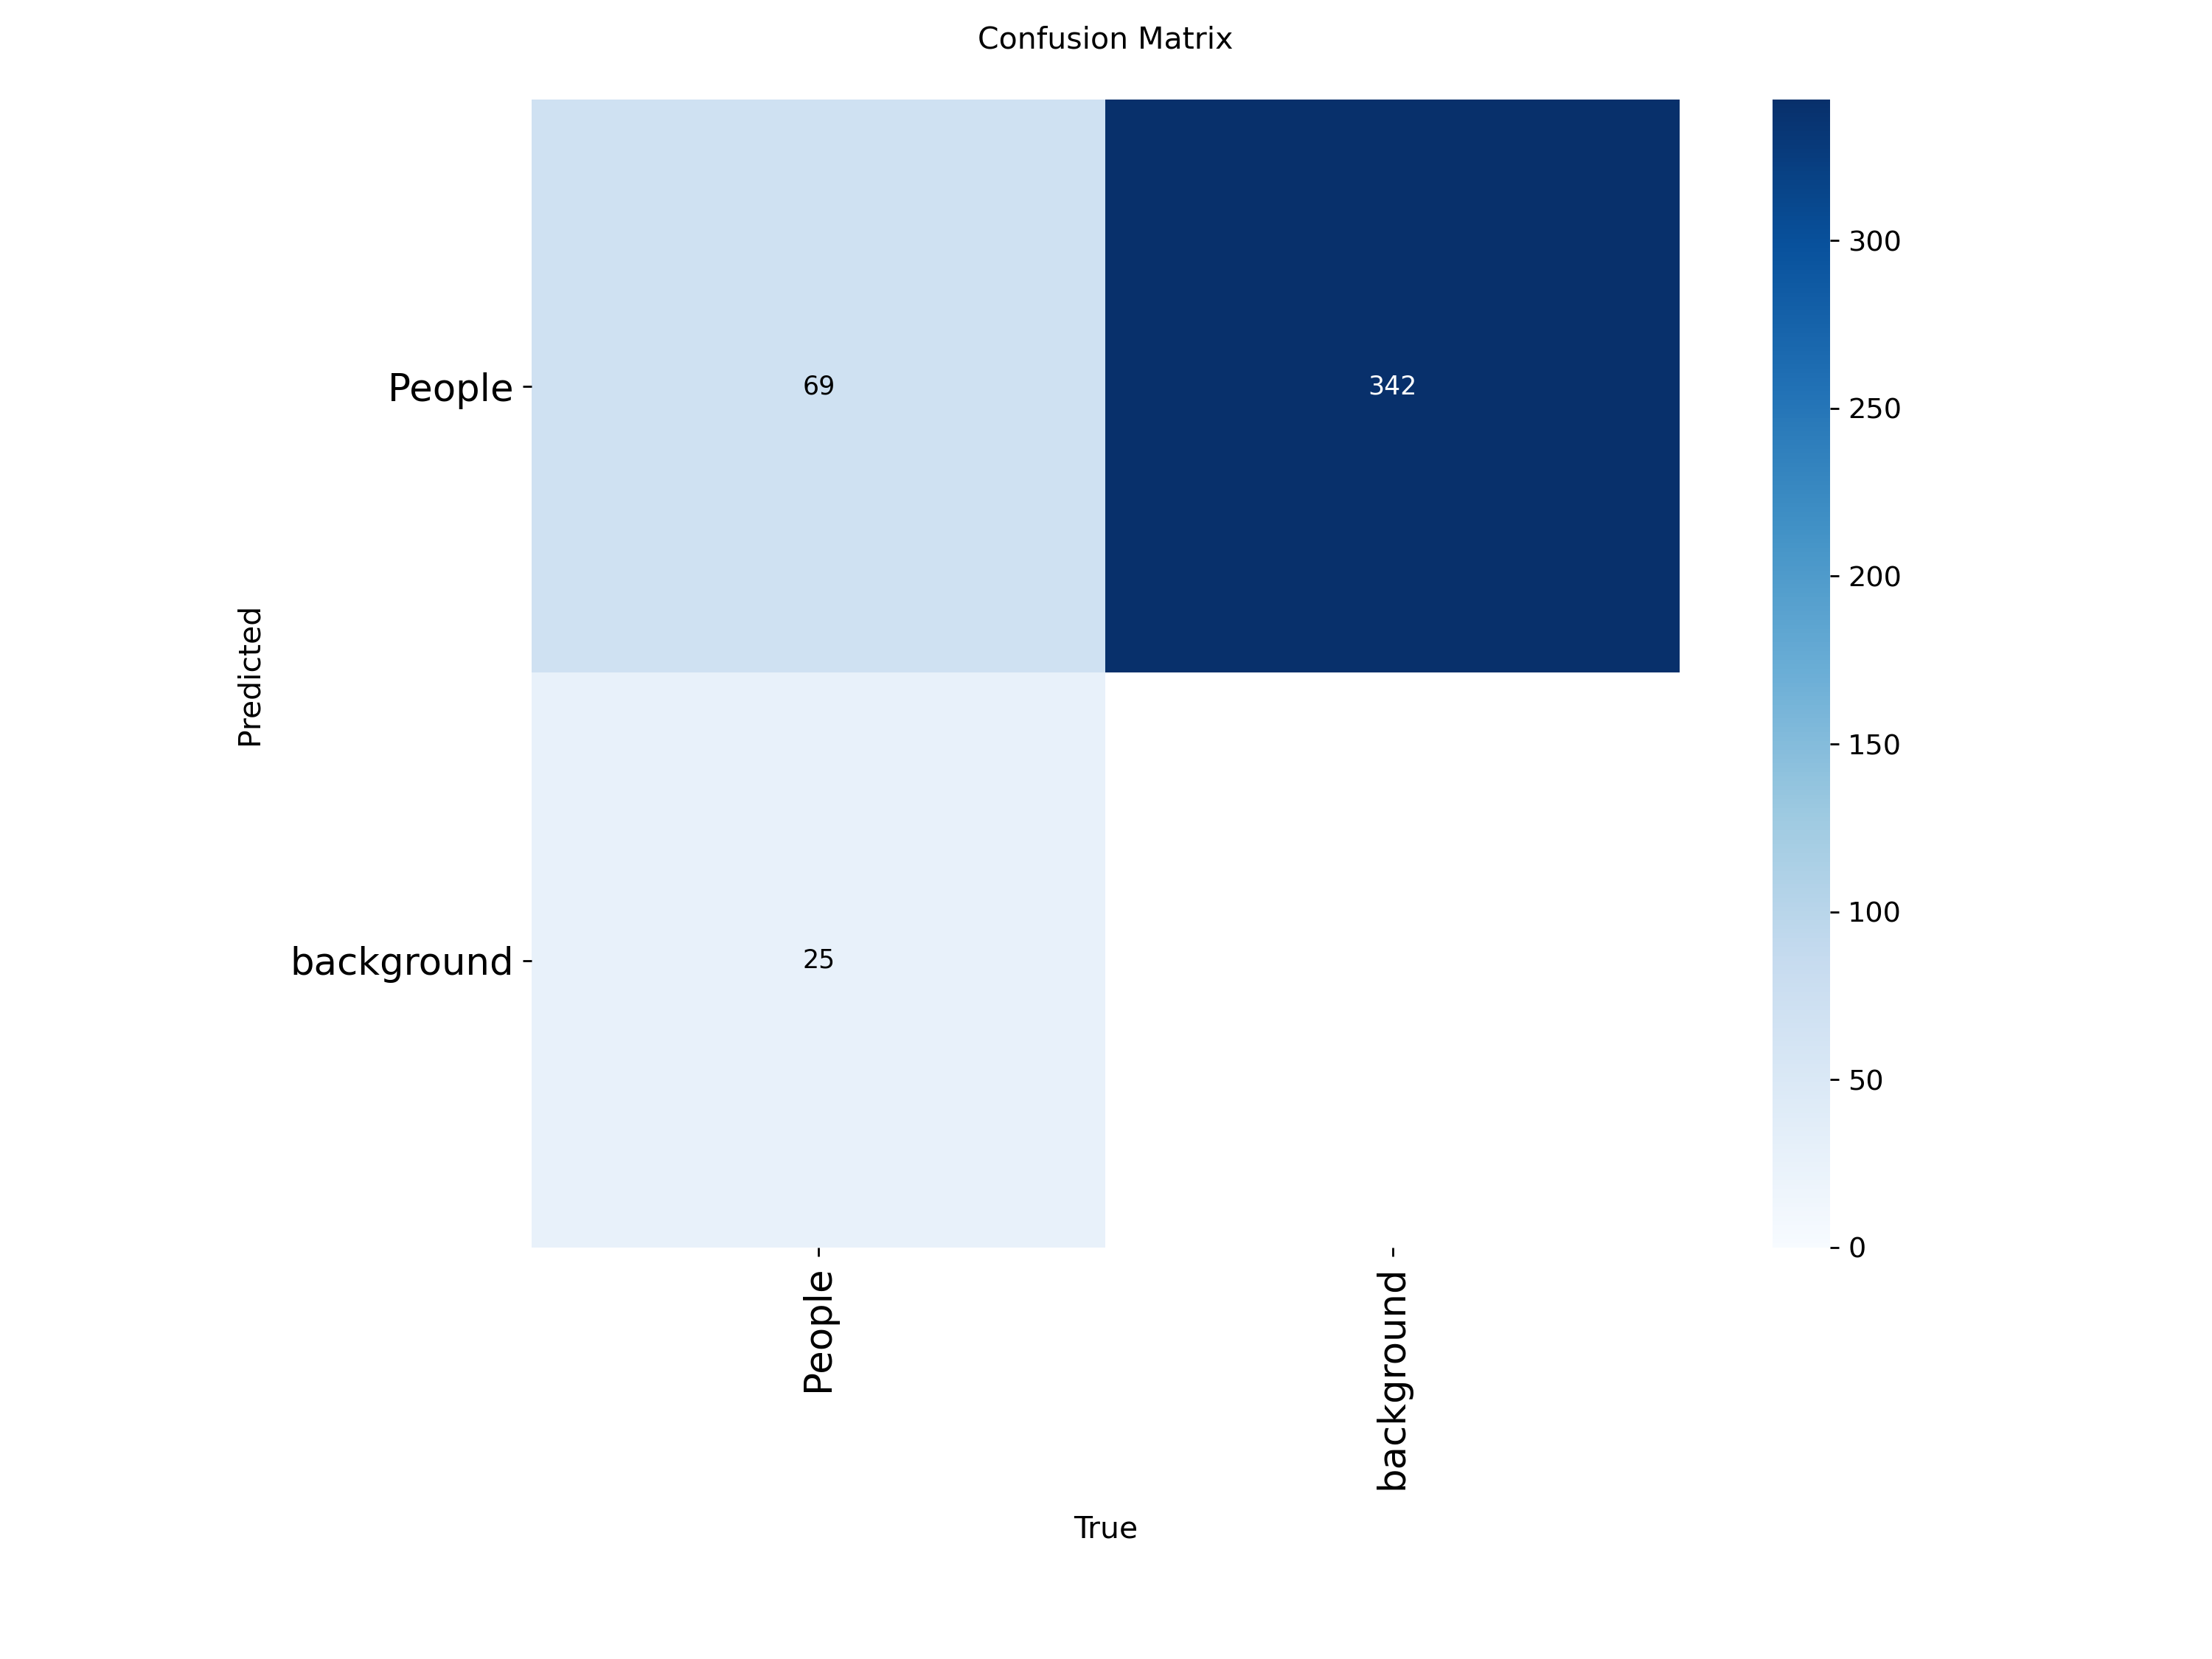

Plot file not found: /content/runs/detect/train/F1_curve.png
Plot file not found: /content/runs/detect/train/PR_curve.png


In [ ]:
from IPython.display import Image, display
import os

# Define the path to the training results directory
train_results_dir = '/content/runs/detect/train' # This should match where your YOLOv8 training results are saved

# List of plots to display
plots_to_display = ['results.png', 'confusion_matrix.png', 'F1_curve.png', 'PR_curve.png']

for plot_file in plots_to_display:
    plot_path = os.path.join(train_results_dir, plot_file)
    if os.path.exists(plot_path):
        print(f"Displaying {plot_file}:")
        display(Image(filename=plot_path))
    else:
        print(f"Plot file not found: {plot_path}")


In [ ]:
from ultralytics import YOLO
from IPython.display import Image, display
import os
import glob

# Load the best trained model (if not already loaded)
model = YOLO('/content/runs/detect/train/weights/best.pt')

# Get some example images from the test set
test_images_path = '/content/Disaster-Survivor-Detection-2/test/images'
example_test_images = glob.glob(os.path.join(test_images_path, '*.jpg'))[:3] # Get first 3 images from test set

# Run inference on the example test images
# Ensure a unique project and name to avoid conflicts with previous predictions
results_test = model.predict(source=example_test_images, save=True, project='runs', name='predict_test_examples', exist_ok=True, imgsz=640)

# Display the predicted test images
# The output directory will be under 'runs/detect/runs/predict_test_examples'
prediction_output_dir_test = '/content/runs/detect/runs/predict_test_examples'
for img_path in example_test_images:
    base_name = os.path.basename(img_path)
    predicted_img_path_test = os.path.join(prediction_output_dir_test, base_name)
    if os.path.exists(predicted_img_path_test):
        print(f"Displaying predictions for test image: {base_name}")
        display(Image(filename=predicted_img_path_test))
    else:
        print(f"Predicted image not found: {predicted_img_path_test}")


0: 640x640 39 Peoples, 32.2ms
1: 640x640 81 Peoples, 32.2ms
2: 640x640 41 Peoples, 32.2ms
Speed: 1.6ms preprocess, 32.2ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/runs/predict_test_examples
Predicted image not found: /content/runs/detect/runs/predict_test_examples/Flood-29_jpg.rf.c75a9a17256d1347beafac754b56671a.jpg
Predicted image not found: /content/runs/detect/runs/predict_test_examples/PTI07_30_2024_000543B_jpg.rf.7a447a9cc1b381372163540fbfba5477.jpg
Predicted image not found: /content/runs/detect/runs/predict_test_examples/People-take-refuge-on-the-roof-of-a-mobile-home_webp.rf.264c5e4f0a9a2b559d62babe7a369793.jpg


Displaying predictions for test image: image0.jpg


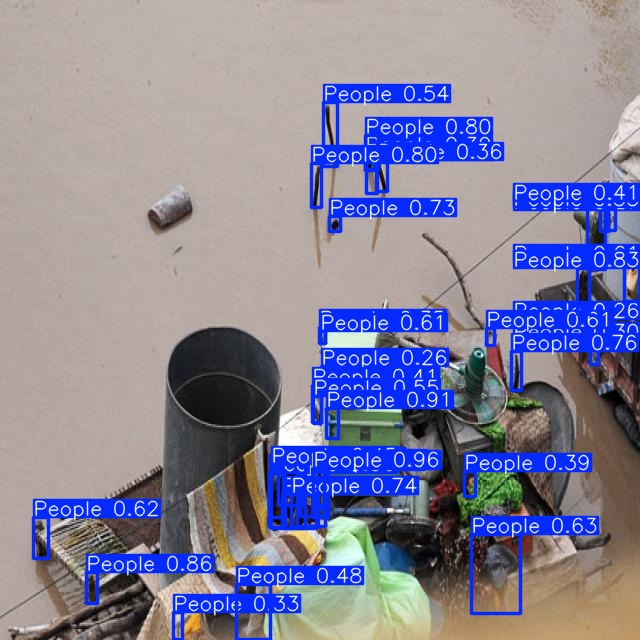

Displaying predictions for test image: image1.jpg


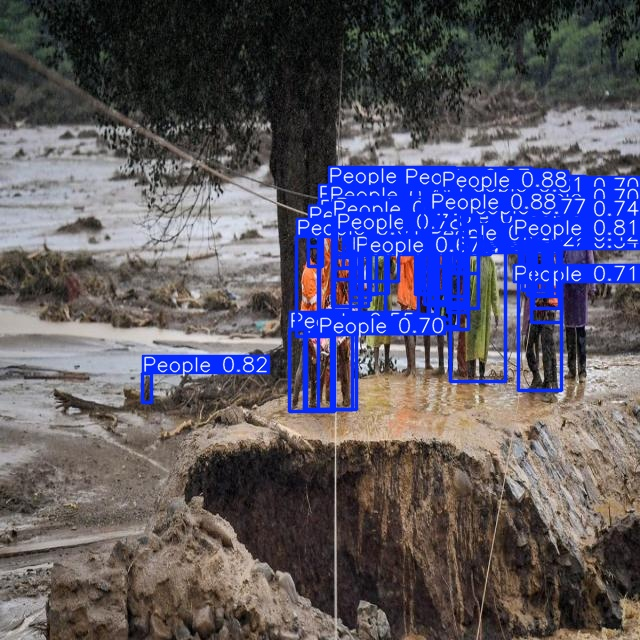

Displaying predictions for test image: image2.jpg


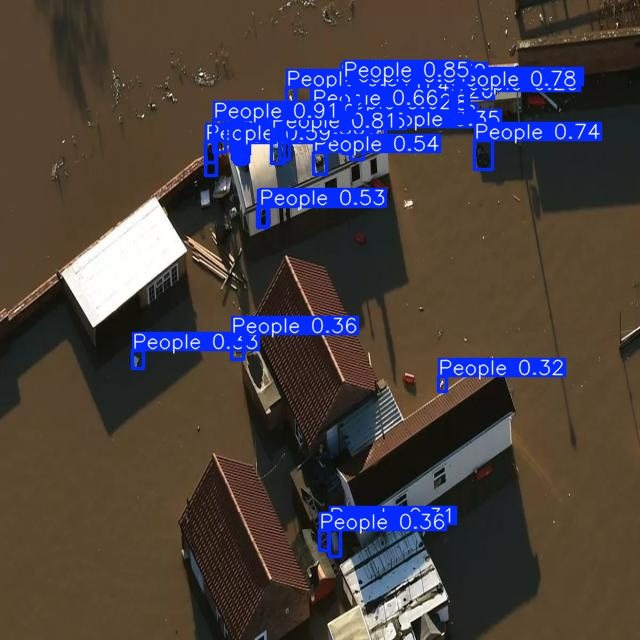

In [ ]:
from IPython.display import Image, display
import os

# The 'results_test' object from the previous cell contains information about the predictions,
# including the paths to the saved images.

if 'results_test' in locals():
    for result in results_test:
        # Each 'result' object has a 'save_dir' (where all results were saved)
        # and 'path' (the original image path). We combine them to get the predicted image path.
        predicted_img_path_test = os.path.join(result.save_dir, os.path.basename(result.path))
        if os.path.exists(predicted_img_path_test):
            print(f"Displaying predictions for test image: {os.path.basename(result.path)}")
            display(Image(filename=predicted_img_path_test))
        else:
            print(f"Predicted image not found: {predicted_img_path_test}")
else:
    print("No 'results_test' object found. Please run the prediction cell first.")